# 3. Merge all the circuits

### 3.1 create csv file
- train.csv (any 3 cricuits)
- test.csv (the rest one circuit)
  
## 3.2 create image folder
- train_images
- test_images

## Circuits Dataset
- train
    - simple circuit
    - montreal circuit
    - montmelo circuit
- test
    - nurburgring circuit

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import torch
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np
import time

In [17]:
# CONSTANT
RAW_BASE_DIR = ""
# merged datasets
BASE_DIR = ""
CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]
TEST_DATASET = 'simple_circuit'

In [18]:
# simple circuit
df_simple_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[0],f"{CIRCUIT_LIST[0]}-labels.csv"))

In [19]:
# montreal circuit
df_montreal_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[1],f"{CIRCUIT_LIST[1]}-labels.csv"))

In [20]:
# montmelo circuit
df_montmelo_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[2],f"{CIRCUIT_LIST[2]}-labels.csv"))

In [21]:
# nurburgring circuit
df_nurburgring_circuit = pd.read_csv(os.path.join(RAW_BASE_DIR,CIRCUIT_LIST[3],f"{CIRCUIT_LIST[3]}-labels.csv"))

# 🗃️ Create All possible subset of the train and test datasets

In [22]:
datasets_list = {
    "simple_circuit":df_simple_circuit,
    "montreal_circuit":df_montreal_circuit,
    "montmelo_circuit":df_montmelo_circuit,
    "nurburgring_circuit":df_nurburgring_circuit
}

In [23]:
start_time = time.time()

for test_circuit in CIRCUIT_LIST:

    # 1. CREATE CSV FILE
    test_dataset = test_circuit
    train_dataset_list = []
    test_dataset_list = []

    # test dataset
    test_dataset_list.append(datasets_list[test_circuit])
    # train dataset
    for circuit in CIRCUIT_LIST:
        if circuit is not test_dataset:
            train_dataset_list.append(datasets_list[circuit])

    print(f"test circuit name: {test_circuit}")
    print(len(train_dataset_list))
    print(len(test_dataset_list))

    # merge dataset
    merged_train_df = pd.concat(train_dataset_list, ignore_index=True)
    merged_test_df = pd.concat(test_dataset_list, ignore_index=True)

    # create dir or check
    os.makedirs(f"{BASE_DIR}/{test_circuit}",exist_ok=True)
    # save files
    merged_train_df.to_csv(f"{BASE_DIR}/{test_circuit}/train.csv", index=False)
    merged_test_df.to_csv(f"{BASE_DIR}/{test_circuit}/test.csv", index=False)


end_time = time.time()
elapsed = end_time - start_time
print(f"time taken: {elapsed:.4f} seconds")

test circuit name: simple_circuit
3
1
test circuit name: montreal_circuit
3
1
test circuit name: montmelo_circuit
3
1
test circuit name: nurburgring_circuit
3
1
time taken: 0.1884 seconds


In [9]:
# start time
start_time = time.time()
error_images = 0
IMG_HEIGHT = 240

for test_circuit in CIRCUIT_LIST:
    
    # RAW_BASE_DIR
    # CREATE TRAIN AND TEST DIR INSIDE BASE OUTPUT DIR
    os.makedirs(os.path.join(BASE_DIR,test_circuit,'train'),exist_ok=True)
    os.makedirs(os.path.join(BASE_DIR,test_circuit,'test'),exist_ok=True)
    print(f"{test_circuit} starting...")
    for circuit in CIRCUIT_LIST:
        # GET THE FULL IMAGE INPUT PATH IF CURRENT `circuit`
        image_path = os.path.join(RAW_BASE_DIR,circuit,'images')
        
        # CREATE FOLDER/CHECK
        os.makedirs(image_path,exist_ok=True)
    
        # GET LIST OF ALL THE `circuit` IMAGES
        image_list = glob.glob(os.path.join(image_path,'*.png'))
    
        # Transform to tensor
        to_tensor = transforms.ToTensor()  # Converts PIL to [C,H,W] FloatTensor in [0,1]
        to_pil = transforms.ToPILImage()   # For visualization or debug
    
        # LOOP THROUGH THE IAMGES
        for path in image_list:
            try:
                # Load image with PIL and convert to RGB
                img = Image.open(path).convert('RGB')
        
                # To tensor and move to GPU
                tensor = to_tensor(img).unsqueeze(0).cuda()  # Shape: [1, 3, H, W]
        
                # Crop last 240 rows
                cropped_tensor = tensor[:, :, -IMG_HEIGHT:, :]  # Shape: [1, 3, 240, W]
        
                # Move to CPU and convert to numpy image (H, W, C) in uint8
                cropped_img_np = (cropped_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        
                # Save using OpenCV
                filename = os.path.basename(path)
    
                # divided path into train and test
                if circuit == test_circuit:
                    save_path = os.path.join(BASE_DIR,test_circuit,'test', filename)
                else: 
                    save_path = os.path.join(BASE_DIR,test_circuit,'train',filename)
                    
                cv2.imwrite(save_path, cv2.cvtColor(cropped_img_np, cv2.COLOR_RGB2BGR))
        
                # print(f"Saved: {save_path}")
        
            except Exception as e:
                print(f"Error processing {path}: {e}")
                error_images += 1
                
        #  end of the loop
    print(f"{test_circuit} completed")
    
# end time
end_time = time.time()
elapsed = end_time - start_time

print(f"Failed to process {error_images} images.")
print(f"Elapsed time: {elapsed:.2f} seconds")

simple_circuit starting...
simple_circuit completed
montreal_circuit starting...
montreal_circuit completed
montmelo_circuit starting...
montmelo_circuit completed
nurburgring_circuit starting...
nurburgring_circuit completed
Failed to process 0 images.
Elapsed time: 1191.46 seconds


### Load merge train and test dataset

In [ ]:
# load train csv
df_train = pd.read_csv(os.path.join(BASE_DIR,'train.csv'))

In [ ]:
# load test csv
df_test = pd.read_csv(os.path.join(BASE_DIR,'test.csv'))

### Categorize angular velocity (w) into 5 categories

In [13]:
# def categorize_w(w):
#     if w < -1.0:
#         return "sharp_right"
#     elif w < -0.1:
#         return "right"
#     elif w <= 0.1:
#         return "straight"
#     elif w <= 1.0:
#         return "left"
#     else:
#         return "sharp_left"
def categorize_w(w):
    if w < -1.0:
        return "sharp_right"
    elif w < -0.09:
        return "right"
    elif w <= 0.09:
        return "straight"
    elif w <= 1.0:
        return "left"
    else:
        return "sharp_left"

In [14]:
df_train['w_category'] = df_train['w'].apply(categorize_w)
df_train['w_category'].unique()

NameError: name 'df_train' is not defined

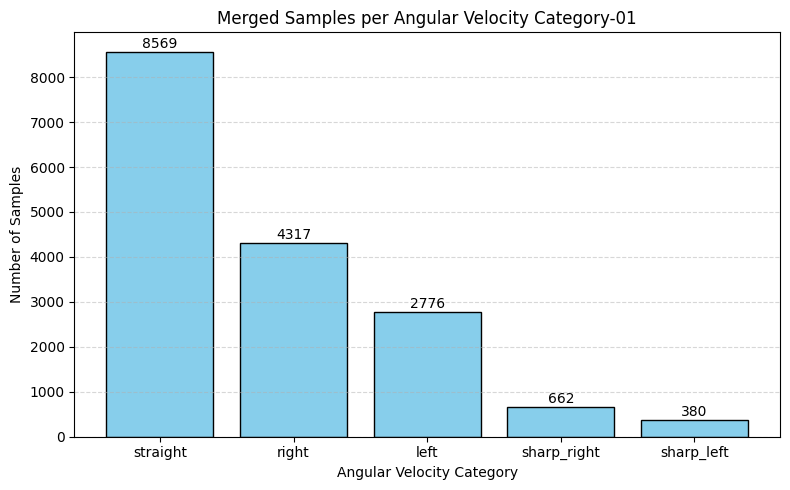

In [38]:
category_counts = df_train['w_category'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# Add counts above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.title(f"Merged Samples per Angular Velocity Category-01")
plt.xlabel("Angular Velocity Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(f"visualization-images/merged-angular_velocity_category_1.png")
plt.show()

## Linear velocity

In [31]:
def categorize_v(v):
    if v <= 6.5:
        return "slow"
    elif v <= 8.0:
        return "moderate"
    elif v <= 9.5:
        return "fast"
    else:
        return "very_fast"

In [32]:
df_train['v_category'] = df_train['v'].apply(categorize_v)
df_train['v_category'].unique()

array(['very_fast', 'fast', 'moderate', 'slow'], dtype=object)

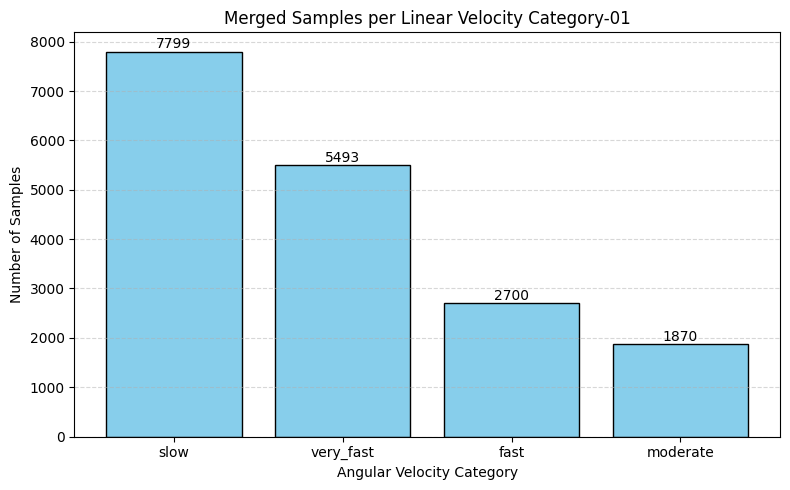

In [33]:
category_counts = df_train['v_category'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# Add counts above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.title(f"Merged Samples per Linear Velocity Category-01")
plt.xlabel("Angular Velocity Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(f"visualization-images/merged-angular_velocity_category_1.png")
plt.show()

# VISUALIZE THE ALL POSSIBLE DATASET

In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
def categorize_w(w):
    if w < -1.0:
        return "sharp_right"
    elif w < -0.1:
        return "right"
    elif w <= 0.1:
        return "straight"
    elif w <= 1.0:
        return "left"
    else:
        return "sharp_left"
        
def categorize_v(v):
    if v <= 6.5:
        return "slow"
    elif v <= 8.0:
        return "moderate"
    elif v <= 9.5:
        return "fast"
    else:
        return "very_fast"

In [15]:
CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]

In [16]:
BASE_DIR = "" 

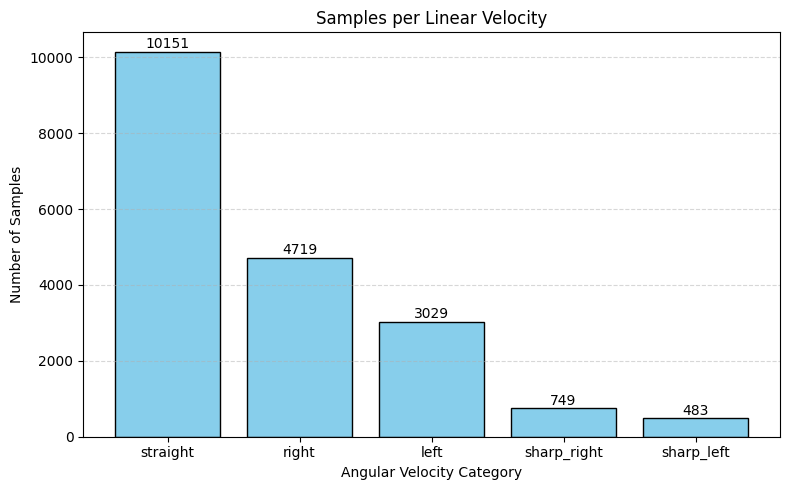

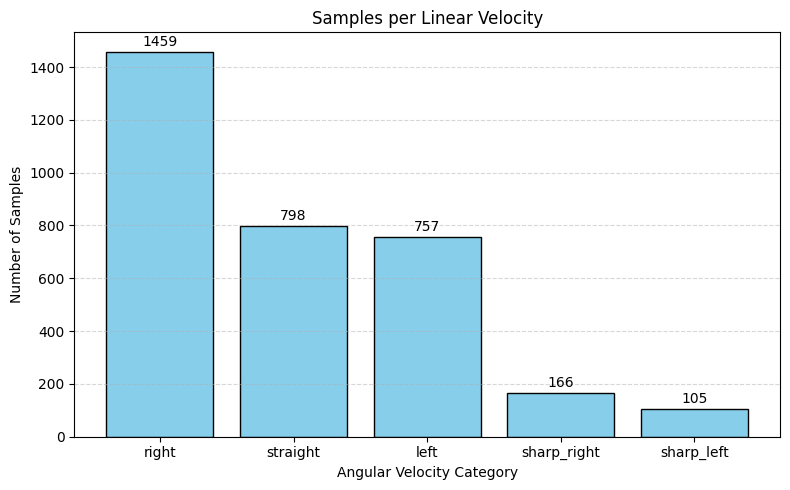

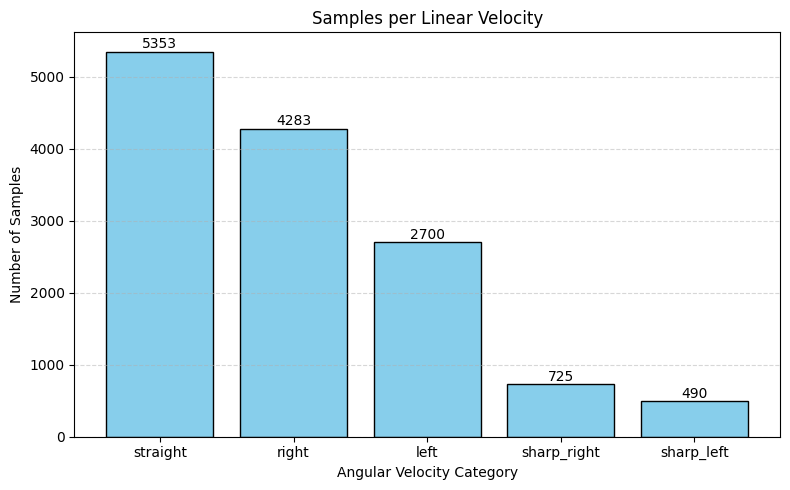

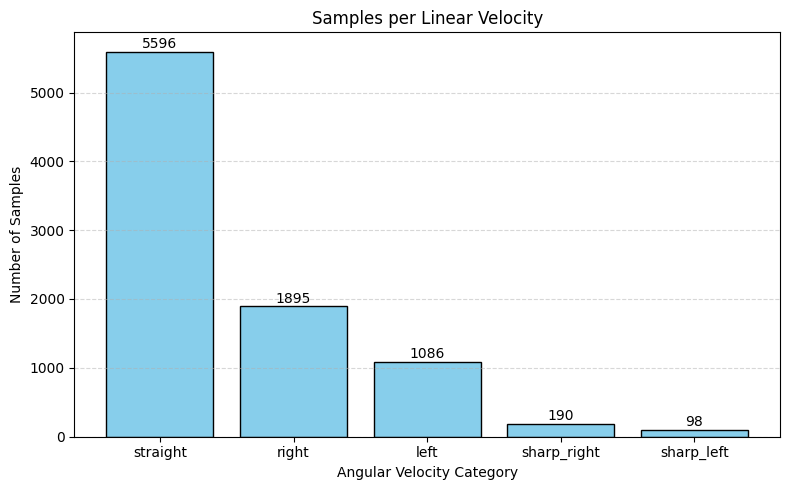

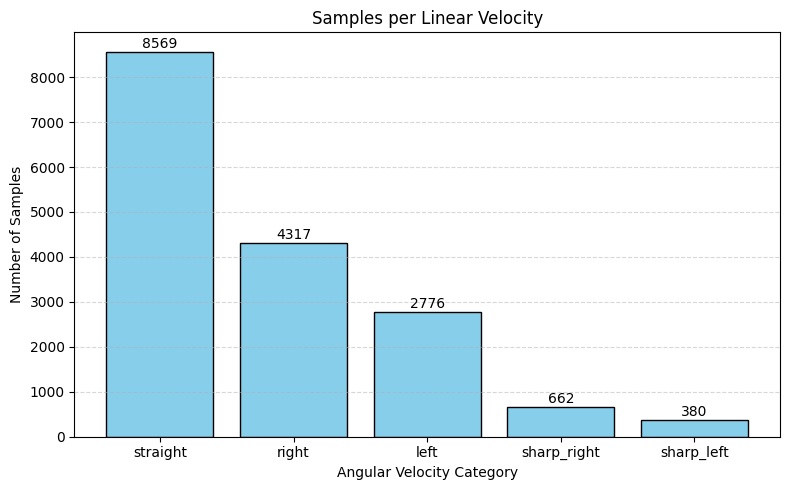

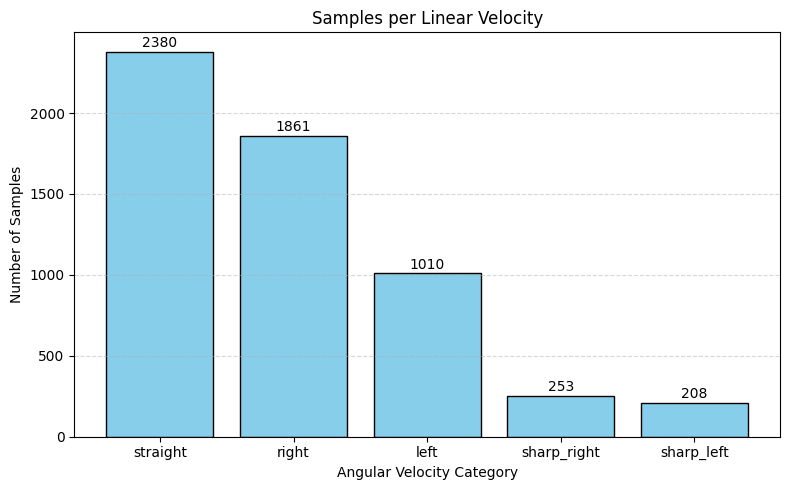

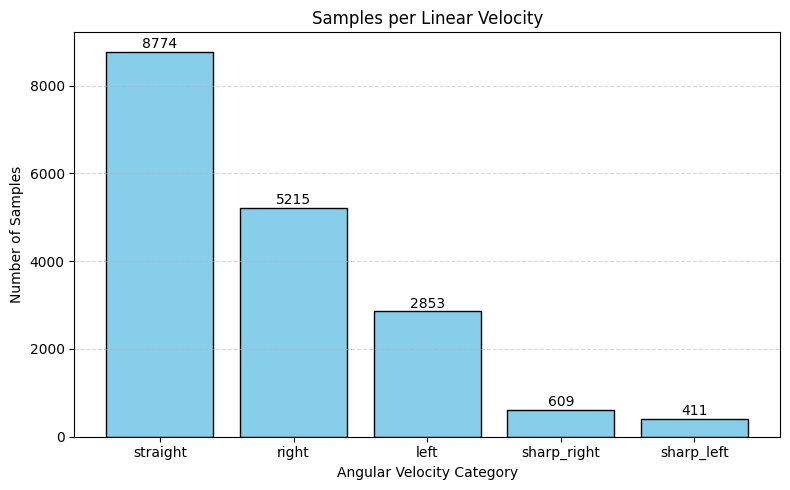

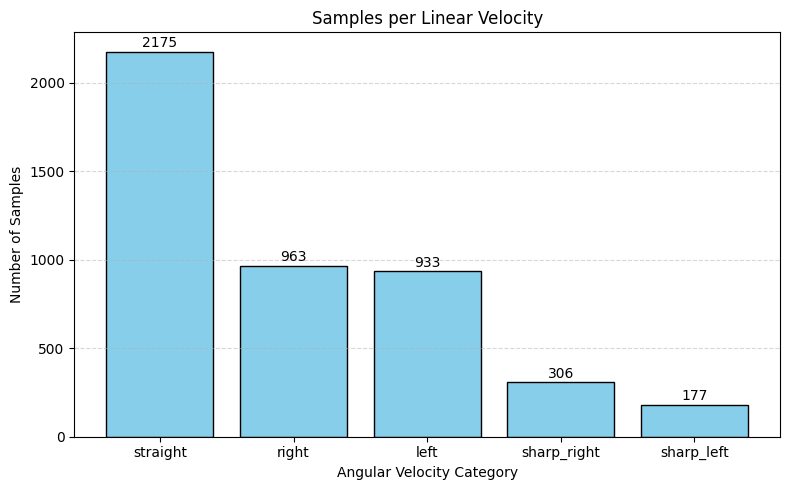

In [18]:
for circuit in CIRCUIT_LIST:
    train_df_vis = pd.read_csv(os.path.join(BASE_DIR,circuit,'train.csv'))
    test_df_vis = pd.read_csv(os.path.join(BASE_DIR,circuit,'test.csv'))

    # train
    train_df_vis['w_category'] = train_df_vis['w'].apply(categorize_w)
    # test
    test_df_vis['w_category'] = test_df_vis['w'].apply(categorize_w)

    # counts
    train_category_counts = train_df_vis['w_category'].value_counts()
    test_category_counts = test_df_vis['w_category'].value_counts()
    

    # train Plot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(train_category_counts.index, train_category_counts.values, color='skyblue', edgecolor='black')
    
    # Add counts above bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)
    
    # Labels and title
    plt.title(f"Samples per Linear Velocity")
    plt.xlabel("Angular Velocity Category")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig(f"visualization-images/new/{circuit}-angular_velocity_train.png")
    plt.show()



    # test Plot
    plt.figure(figsize=(8, 5))
    bars = plt.bar(test_category_counts.index, test_category_counts.values, color='skyblue', edgecolor='black')
    
    # Add counts above bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)
    
    # Labels and title
    plt.title(f"Samples per Linear Velocity")
    plt.xlabel("Angular Velocity Category")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig(f"visualization-images/new/{circuit}-angular_velocity_test.png")
    plt.show()

# archive

In [ ]:
datasets_list = {
    "simple_circuit":df_simple_circuit,
    "montreal_circuit":df_montreal_circuit,
    "montmelo_circuit":df_montmelo_circuit,
    "nurburgring_circuit":df_nurburgring_circuit
}
train_dataset_list = []
test_dataset_list = []
for circuit in CIRCUIT_LIST:
    if circuit == TEST_DATASET:
        test_dataset_list.append(datasets_list[circuit])
    else:
        train_dataset_list.append(datasets_list[circuit])

print(len(train_dataset_list))
print(len(test_dataset_list))


merged_train_df = pd.concat(train_dataset_list, ignore_index=True)
merged_test_df = pd.concat(test_dataset_list, ignore_index=True)
merged_train_df.to_csv("csv_files/train.csv", index=False)
merged_test_df.to_csv("csv_files/test.csv", index=False)

In [10]:
CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]

for circuit in CIRCUIT_LIST:
    path = ""
    !ls {path} | wc -l

ls: cannot access '/home/codezerro/Desktop/all_customs_datasets/v2/counter_clockwise_customs_datasets_v2/follow-line-custom-raw-dataset-v2/simple_circuit/images': No such file or directory
0
ls: cannot access '/home/codezerro/Desktop/all_customs_datasets/v2/counter_clockwise_customs_datasets_v2/follow-line-custom-raw-dataset-v2/montreal_circuit/images': No such file or directory
0
ls: cannot access '/home/codezerro/Desktop/all_customs_datasets/v2/counter_clockwise_customs_datasets_v2/follow-line-custom-raw-dataset-v2/montmelo_circuit/images': No such file or directory
0
ls: cannot access '/home/codezerro/Desktop/all_customs_datasets/v2/counter_clockwise_customs_datasets_v2/follow-line-custom-raw-dataset-v2/nurburgring_circuit/images': No such file or directory
0
